In [85]:
import pandas as pd

orders = pd.read_csv('../data/olist_orders_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')

print(orders.shape)
print(orders.dtypes)

(99441, 8)
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [86]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print(orders['order_status'].value_counts())

print("Период данных:")
print(f"С: {orders['order_purchase_timestamp'].min()}")
print(f"По: {orders['order_purchase_timestamp'].max()}")

print("Пропуски:")
print(orders.isnull().sum())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
Период данных:
С: 2016-09-04 21:15:19
По: 2018-10-17 17:30:18
Пропуски:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [87]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print(payments.dtypes)

df = pd.merge(orders_delivered, payments, on='order_id', how='left')

arppu = df['payment_value'].sum() / df['customer_id'].nunique()
print(f"Всего выручка: {df['payment_value'].sum():,.0f} BRL")
print(f"Уникальных покупателей: {df['customer_id'].nunique():,}")
print(f"ARPPU: {arppu:.2f} BRL")

order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object
Всего выручка: 15,422,462 BRL
Уникальных покупателей: 96,478
ARPPU: 159.85 BRL


In [88]:
df['order_delivered_customer_date'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month']=df['order_purchase_timestamp'].dt.to_period('M')
delivered_grouped_df = df.groupby('month').agg(payment_value_agg = ('payment_value','sum')
                                                                  ,order_id_agg = ('order_id', 'nunique')
                                                                  ,customer_id_agg = ('customer_id', 'nunique')).reset_index()
delivered_grouped_df.tail(15)

,month,payment_value_agg,order_id_agg,customer_id_agg
8,2017-06,490225.60,3135,3135
9,2017-07,566403.93,3872,3872
10,2017-08,646000.61,4193,4193
11,2017-09,701169.99,4150,4150
12,2017-10,751140.27,4478,4478
13,2017-11,1153528.05,7289,7289
14,2017-12,843199.17,5513,5513
15,2018-01,1078606.86,7069,7069
16,2018-02,966510.88,6555,6555
17,2018-03,1120678.00,7003,7003


<Axes: xlabel='month'>

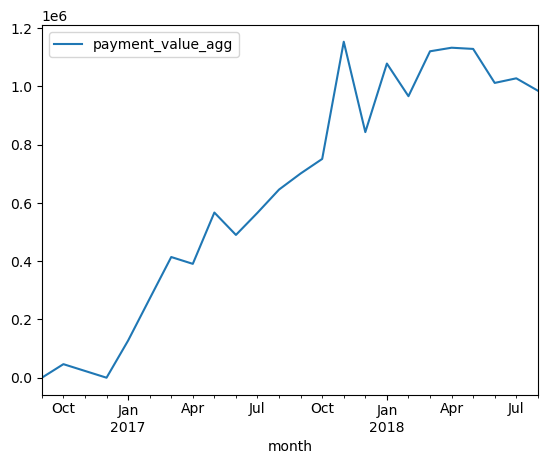

In [89]:
delivered_grouped_df.plot(kind = 'line', x = 'month', y = 'payment_value_agg')

In [90]:
df_cohort = df.groupby('customer_id').agg(cohort_month = ('month', 'min'))
df = pd.merge(df, df_cohort, on = 'customer_id', how = 'left')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,month,cohort_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-02 10:56:33,2017-10-18,1.0,credit_card,1.0,18.12,2017-10,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-02 10:56:33,2017-10-18,3.0,voucher,1.0,2.00,2017-10,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-02 10:56:33,2017-10-18,2.0,voucher,1.0,18.59,2017-10,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-07-24 20:41:37,2018-08-13,1.0,boleto,1.0,141.46,2018-07,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-08 08:38:49,2018-09-04,1.0,credit_card,3.0,179.12,2018-08,2018-08


In [91]:
df['cohort_index'] = (df['month'].dt.year - df['cohort_month'].dt.year)*12 + (df['month'].dt.month - df['cohort_month'].dt.month)

In [92]:
df[['customer_id', 'month', 'cohort_month', 'cohort_index']].head(10)

,customer_id,month,cohort_month,cohort_index
0,9ef432eb6251297304e76186b10a928d,2017-10,2017-10,0
1,9ef432eb6251297304e76186b10a928d,2017-10,2017-10,0
2,9ef432eb6251297304e76186b10a928d,2017-10,2017-10,0
3,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07,2018-07,0
4,41ce2a54c0b03bf3443c3d931a367089,2018-08,2018-08,0
5,f88197465ea7920adcdbec7375364d82,2017-11,2017-11,0
6,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02,2018-02,0
7,503740e9ca751ccdda7ba28e9ab8f608,2017-07,2017-07,0
8,9bdf08b4b3b52b5526ff42d37d47f222,2017-05,2017-05,0
9,f54a9f0e6b351c431402b8461ea51999,2017-01,2017-01,0


In [96]:
pivot = df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().unstack()
retention = pivot.divide(pivot[0], axis=0) * 100
print(retention.iloc[:10, :6])

cohort_index      0
cohort_month       
2016-09       100.0
2016-10       100.0
2016-12       100.0
2017-01       100.0
2017-02       100.0
2017-03       100.0
2017-04       100.0
2017-05       100.0
2017-06       100.0
2017-07       100.0


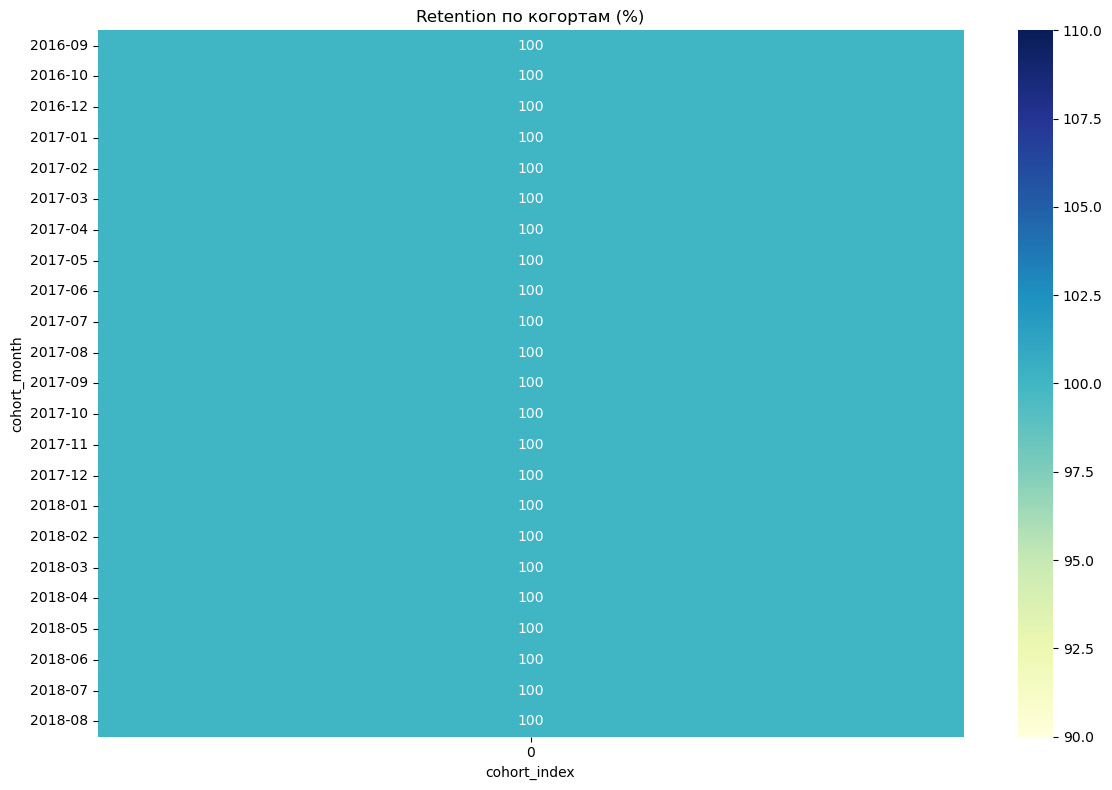

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Retention по когортам (%)')
plt.tight_layout()
plt.show()

In [117]:
group_credit = payments[payments['payment_type']=='credit_card']
group_voucher = payments[payments['payment_type']=='voucher']

In [118]:
print('Для кредиток\nРазмер: ', group_credit.shape[0], 'строк\nСреднее: ', f"{group_credit['payment_value'].mean():,.2f}")
print('\nДля ваучеров\nРазмер: ', group_voucher.shape[0], 'строк\nСреднее: ', f"{group_voucher['payment_value'].mean():,.2f}")

Для кредиток
Размер:  76795 строк
Среднее:  163.32

Для ваучеров
Размер:  5775 строк
Среднее:  65.70


In [126]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(group_credit['payment_value'], group_voucher['payment_value'])
print(f'p-value: {p_value:.2e}')

p-value: 3.75e-238


In [136]:
ci_credit = tuple(round(x, 2) for x in stats.t.interval(0.95, df=len(group_credit['payment_value'])-1, loc=group_credit['payment_value'].mean(), scale=stats.sem(group_credit['payment_value'])))
ci_voucher = tuple(round(x, 2) for x in stats.t.interval(0.95, df=len(group_voucher['payment_value'])-1, loc=group_voucher['payment_value'].mean(), scale=stats.sem(group_voucher['payment_value'])))

In [137]:
print(f"Кредитка: среднее={group_credit['payment_value'].mean():.2f}, 95% ДИ={ci_credit}")
print(f"Ваучер:   среднее={group_voucher['payment_value'].mean():.2f}, 95% ДИ={ci_voucher}")

Кредитка: среднее=163.32, 95% ДИ=(161.75, 164.89)
Ваучер:   среднее=65.70, 95% ДИ=(62.72, 68.68)
